# Lasso Linear Regression: 
### Coordinate descent, soft thresholding, sparsity


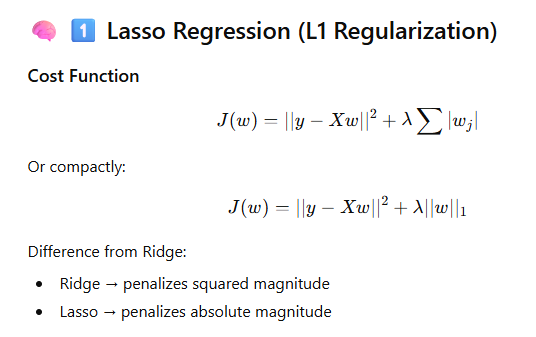

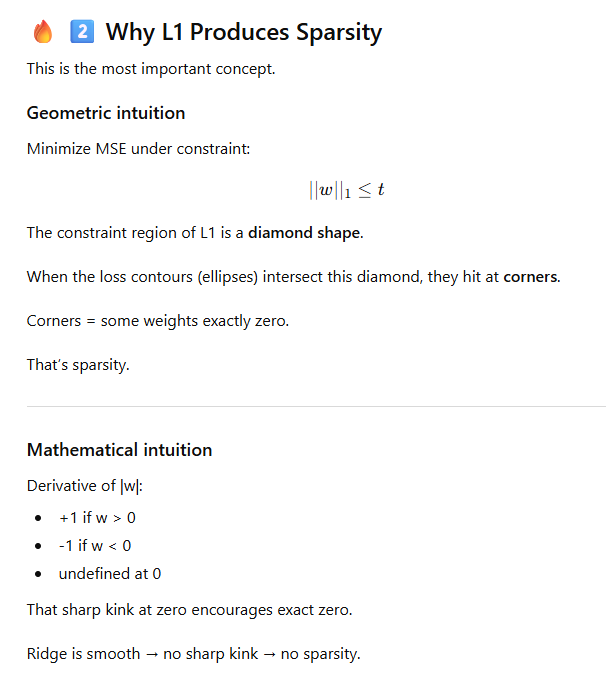

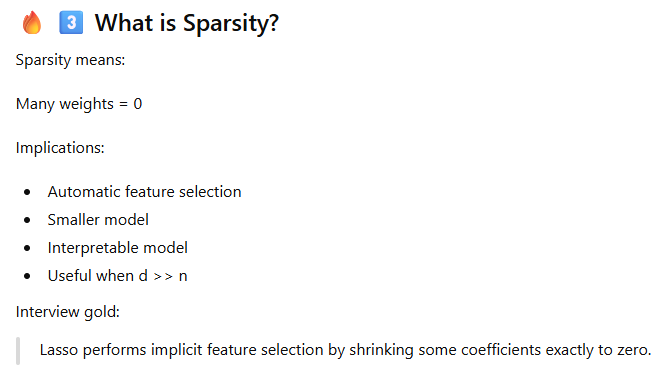

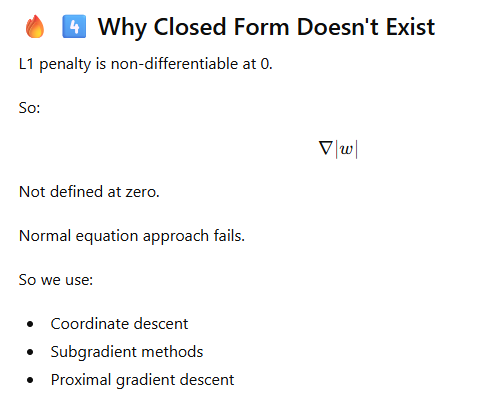

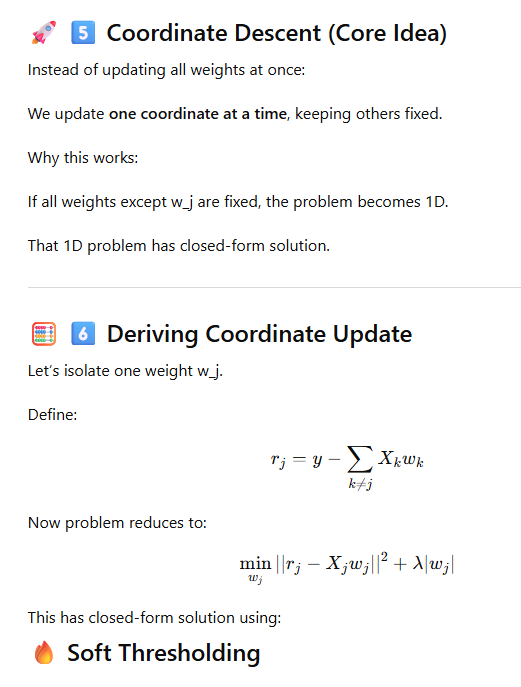

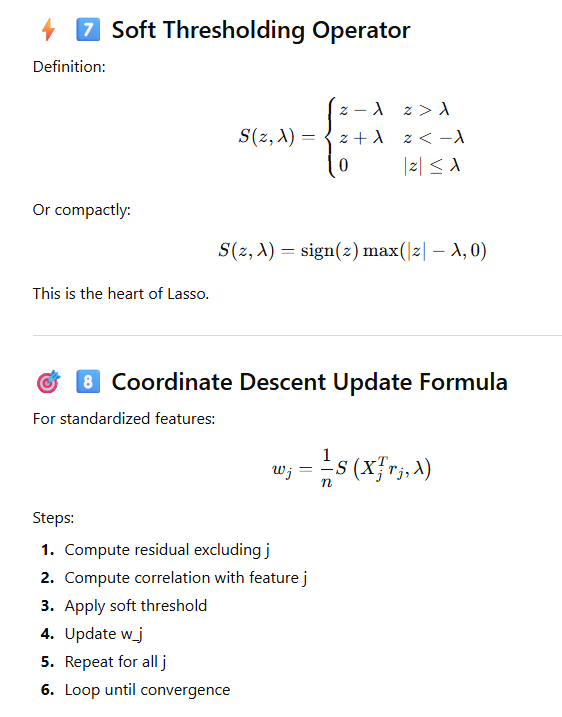

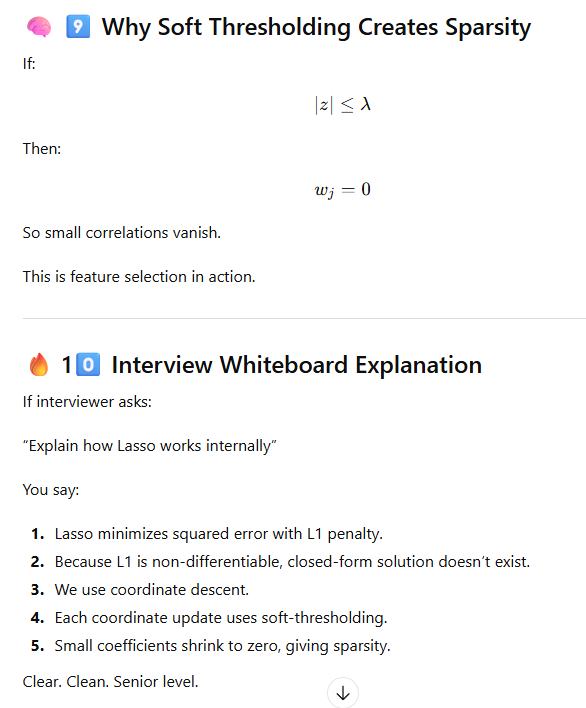

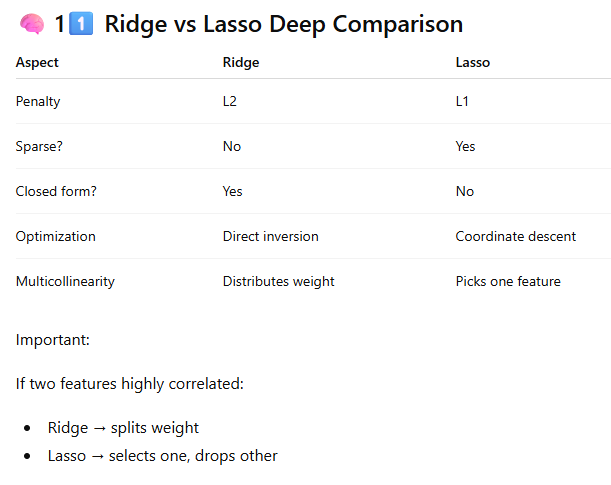

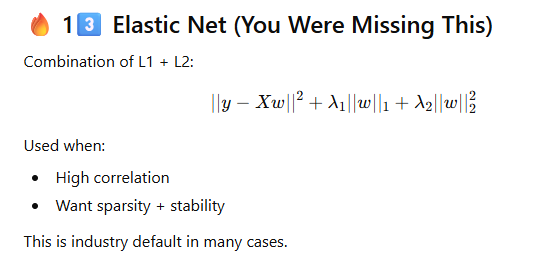

In [1]:
import numpy as np

In [2]:
# Soft threshold function
def soft_threshold(z, lam):
    if z > lam:
        return z - lam
    elif z < -lam:
        return z + lam
    else:
        return 0.0

In [3]:
def soft_threshold_vec(z, lam):
    return np.sign(z) * np.maximum(np.abs(z) - lam, 0.0)


In [4]:
# Standardization
def standardize(X):
    mean = np.mean(X, axis=0)
    std = np.std(X, axis=0)
    return (X - mean) / std, mean, std

In [6]:
# Lasso via coordinate descent
def lasso_coordinate_descent(X, y, lam, iterations=1000):
    m, n = X.shape
    w = np.zeros(n)

    for _ in range(iterations):
        for j in range(n):

            # compute residual excluding j
            y_pred = X @ w
            residual = y - y_pred + X[:, j] * w[j]

            rho = np.dot(X[:, j], residual)

            w[j] = soft_threshold(rho, lam) / np.dot(X[:, j], X[:, j])

    return w

In [7]:
# Demo Sparsity

np.random.seed(42)

X = np.random.randn(100, 10)
true_w = np.array([5,0,0,3,0,0,0,2,0,0])
y = X @ true_w + np.random.randn(100)

X_std, _, _ = standardize(X)

w = lasso_coordinate_descent(X_std, y, lam=1.0)

print('Learned weights: ', w)

Learned weights:  [ 4.36067626 -0.04215607 -0.01515541  3.04625264 -0.12992236  0.0645228
 -0.16484634  1.78320593  0.03993354 -0.04860198]


In [1]:
# Visualization from scratch

import numpy as np
import matplotlib.pyplot as plt

# Sofft threshold function
def soft_threshold(z, lam):
    return np.sign(z) * np.maximum(np.abs(z) - lam, 0.0)

# Standardization
def standardize(X):
    mean = np.mean(X, axis=0)
    std = np.std(X,axis=0)
    return (X - mean) / std, mean, std

In [2]:
# Lasso via Coordinate Desccent

def lasso_coordinate_descent(X, y, lam, iterations=1000):
    m, n = X.shape
    w = np.zeros(n)

    for _ in range(iterations):
        for j in range(n):
            # Compute residual excluding j
            y_pred = X @ w
            residual = y - y_pred + X[:, j] * w[j]

            rho = np.dot(X[:, j], residual)

            w[j] = soft_threshold(rho, lam) / np.dot(X[:, j], X[:, j])

    return w


In [4]:
# Generate Sparse Dataset
np.random.seed(42)

m = 100
n = 10

X = np.random.randn(m, n)

In [5]:
# True sparse weights
true_w = np.array([5,0,0,3,0,0,0,2,0,0])

y = X @ true_w + np.random.randn(m) * 0.5

# Standardize
X_std, mean, std = standardize(X)

In [6]:
# Train with differnet lambdas

lam_small = 0.1
lam_large = 5.0

w_small = lasso_coordinate_descent(X-std, y, lam_small)
w_large = lasso_coordinate_descent(X_std, y, lam_large)

print('True Weights: \n', true_w)
print('\nLasso Weights (Small): \n', w_small)
print('\nLasso Weights (large): \n', w_large)



True Weights: 
 [5 0 0 3 0 0 0 2 0 0]

Lasso Weights (Small): 
 [ 4.17059872 -1.53196232 -0.5930692   2.75098665 -0.59692    -1.14624769
 -1.37990889  1.46614857 -0.93208682 -1.05186567]

Lasso Weights (large): 
 [ 4.37116141 -0.         -0.          2.98567026 -0.01822262  0.00658982
 -0.01799517  1.74084196  0.         -0.        ]


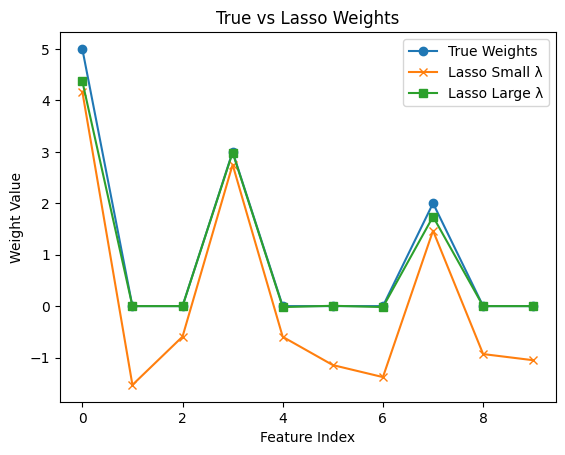

In [8]:
# Plot Weight Comparison
plt.figure()
plt.plot(true_w, marker='o')
plt.plot(w_small, marker='x')
plt.plot(w_large, marker='s')
plt.title("True vs Lasso Weights")
plt.xlabel("Feature Index")
plt.ylabel("Weight Value")
plt.legend(["True Weights", "Lasso Small λ", "Lasso Large λ"])
plt.show()


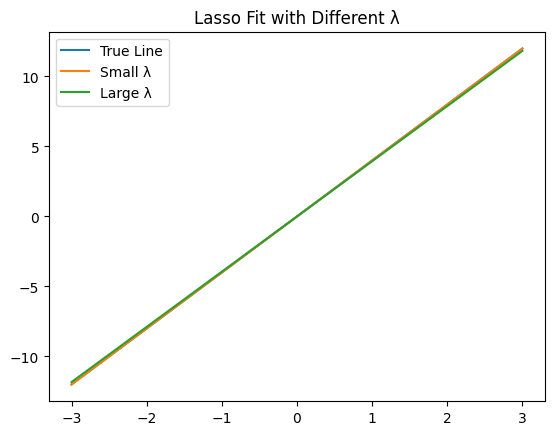

In [9]:
# Prediction Visualization

X_1d = np.linspace(-3, 3, 100).reshape(-1, 1)
y_true = 4 * X_1d.squeeze()

X_1d_std, mean1, std1 = standardize(X_1d)

w_1d_small = lasso_coordinate_descent(X_1d_std, y_true, lam=0.1)
w_1d_large = lasso_coordinate_descent(X_1d_std, y_true, lam=10)

y_pred_small = X_1d_std @ w_1d_small
y_pred_large = X_1d_std @ w_1d_large

plt.figure()
plt.plot(X_1d, y_true)
plt.plot(X_1d, y_pred_small)
plt.plot(X_1d, y_pred_large)
plt.title("Lasso Fit with Different λ")
plt.legend(["True Line", "Small λ", "Large λ"])
plt.show()